# Maize Yield Prediction — Data Cleaning, Handling & Preprocessing
### Crop Yield Prediction Based on Weather and Soil Data
**Federal University of Technology, Minna — Department of Information Technology**

This notebook implements the data-preparation stages of the project methodology
(Chapter Three, sections 3.2–3.8) on the real dataset, scoped to **maize**, and ends
with a preliminary **XGBoost** model (section 3.9.3) to confirm the prepared data is
model-ready.

**Pipeline:** Load → correct the `None` sentinel → scope to maize → clean (duplicates,
ranges, formatting) → handle missing data → EDA → encode → normalise → split → preliminary XGBoost.

> Run top-to-bottom. Requires: `pandas numpy scikit-learn xgboost matplotlib seaborn`.

## 0. Setup

In [1]:
import warnings, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)
RNG = 42          # fixed seed -> reproducible results
DATA = "crop_yield_dataset.csv"   # adjust path if needed

## 1. Loading the Data — and the `"None"` Sentinel Trap

The single most important handling decision in this dataset.

`pandas.read_csv()` treats the string `"None"` as missing (`NaN`) **by default**, because
`'None'` is in its built-in `na_values` list. In this dataset, `"None"` is a **real category**:

* `Irrigation = "None"` → the field is **rainfed** (no irrigation system installed)
* `Previous_Crop = "None"` → **no previous crop** (fallow / first cultivation)

If we accept the default parsing, we would "discover" thousands of missing values that are
not missing, and then *impute* over genuine information — corrupting the data. We read the
file twice to make the contrast explicit.

In [2]:
# WRONG way (default) — 'None' becomes NaN
df_naive = pd.read_csv(DATA)

# RIGHT way — keep 'None' as a literal category; only truly blank fields are missing
NA_TOKENS = ["", "NA", "N/A", "NaN", "nan", "null", "NULL"]   # note: 'None' deliberately excluded
df = pd.read_csv(DATA, keep_default_na=False, na_values=NA_TOKENS)

print("Naive read — cells flagged as missing:")
print(df_naive.isna().sum()[lambda s: s > 0], "\n")
print("Correct read — genuine missing cells:", int(df.isna().sum().sum()))

Naive read — cells flagged as missing:
Irrigation       2538
Previous_Crop    2031
dtype: int64 

Correct read — genuine missing cells: 0


In [3]:
# Relabel the sentinel so its meaning is explicit and it is never mistaken for a gap
df["Irrigation"]    = df["Irrigation"].replace({"None": "Rainfed"})
df["Previous_Crop"] = df["Previous_Crop"].replace({"None": "No_Previous_Crop"})
df.head()

,Crop,Region,Soil_Type,Soil_pH,Rainfall_mm,Temperature_C,Humidity_pct,Fertilizer_Used_kg,Irrigation,Pesticides_Used_kg,Planting_Density,Previous_Crop,Yield_ton_per_ha
0,Maize,Region_C,Sandy,7.01,1485.4,19.7,40.3,105.1,Drip,10.2,23.2,Rice,101.48
1,Barley,Region_D,Loam,5.79,399.4,29.1,55.4,221.8,Sprinkler,35.5,7.4,Barley,127.39
2,Rice,Region_C,Clay,7.24,980.9,30.5,74.4,61.2,Sprinkler,40.0,5.1,Wheat,68.99
3,Maize,Region_D,Loam,6.79,1054.3,26.4,62.0,257.8,Drip,42.7,23.7,No_Previous_Crop,169.06
4,Maize,Region_D,Sandy,5.96,744.6,20.4,70.9,195.8,Drip,25.5,15.6,Maize,118.71


## 2. Scope: Restrict to Maize

The study focuses on maize (*Zea mays* L.) only (Objective/Scope, Chapter 1.7), so a
crop-specific model can be built rather than a diluted multi-crop one.

In [4]:
maize = df[df["Crop"] == "Maize"].copy().reset_index(drop=True)

NUMERIC = ["Soil_pH","Rainfall_mm","Temperature_C","Humidity_pct",
           "Fertilizer_Used_kg","Pesticides_Used_kg","Planting_Density"]
CATEG   = ["Region","Soil_Type","Irrigation","Previous_Crop"]
TARGET  = "Yield_ton_per_ha"

print("Maize records:", maize.shape[0], "| columns:", maize.shape[1])
maize[NUMERIC + [TARGET]].describe().T.round(2)

Maize records: 2477 | columns: 13


,count,mean,std,min,25%,50%,75%,max
Soil_pH,2477.0,6.53,0.57,5.50,6.04,6.54,7.01,7.50
Rainfall_mm,2477.0,849.16,374.46,200.10,522.60,853.80,1169.30,1499.40
Temperature_C,2477.0,24.91,5.81,15.00,19.90,24.70,30.00,35.00
Humidity_pct,2477.0,60.48,17.33,30.00,45.40,60.70,75.50,90.00
Fertilizer_Used_kg,2477.0,175.17,71.70,50.50,114.00,176.00,237.60,299.80
Pesticides_Used_kg,2477.0,25.04,14.24,0.00,12.60,25.60,37.40,50.00
Planting_Density,2477.0,14.91,5.84,5.00,9.80,14.90,19.90,25.00
Yield_ton_per_ha,2477.0,118.11,38.03,35.65,86.98,118.37,150.36,207.21


## 3. Exploratory Data Analysis (3.2)

Summary statistics, distributions, correlations and outlier checks — used to decide what
cleaning and preprocessing the data actually needs.

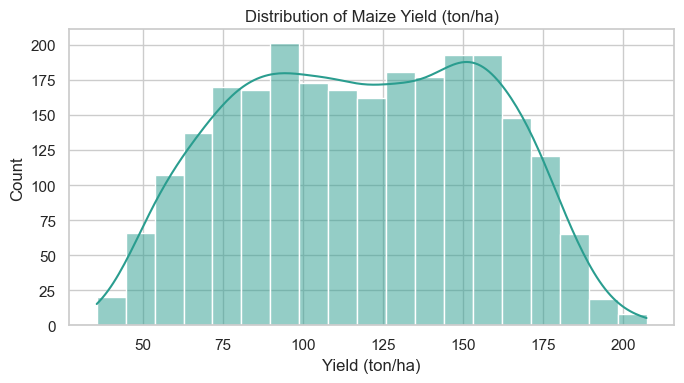

In [5]:
# Target distribution
plt.figure(figsize=(7,4))
sns.histplot(maize[TARGET], kde=True, color="#2a9d8f")
plt.title("Distribution of Maize Yield (ton/ha)"); plt.xlabel("Yield (ton/ha)")
plt.tight_layout(); plt.show()

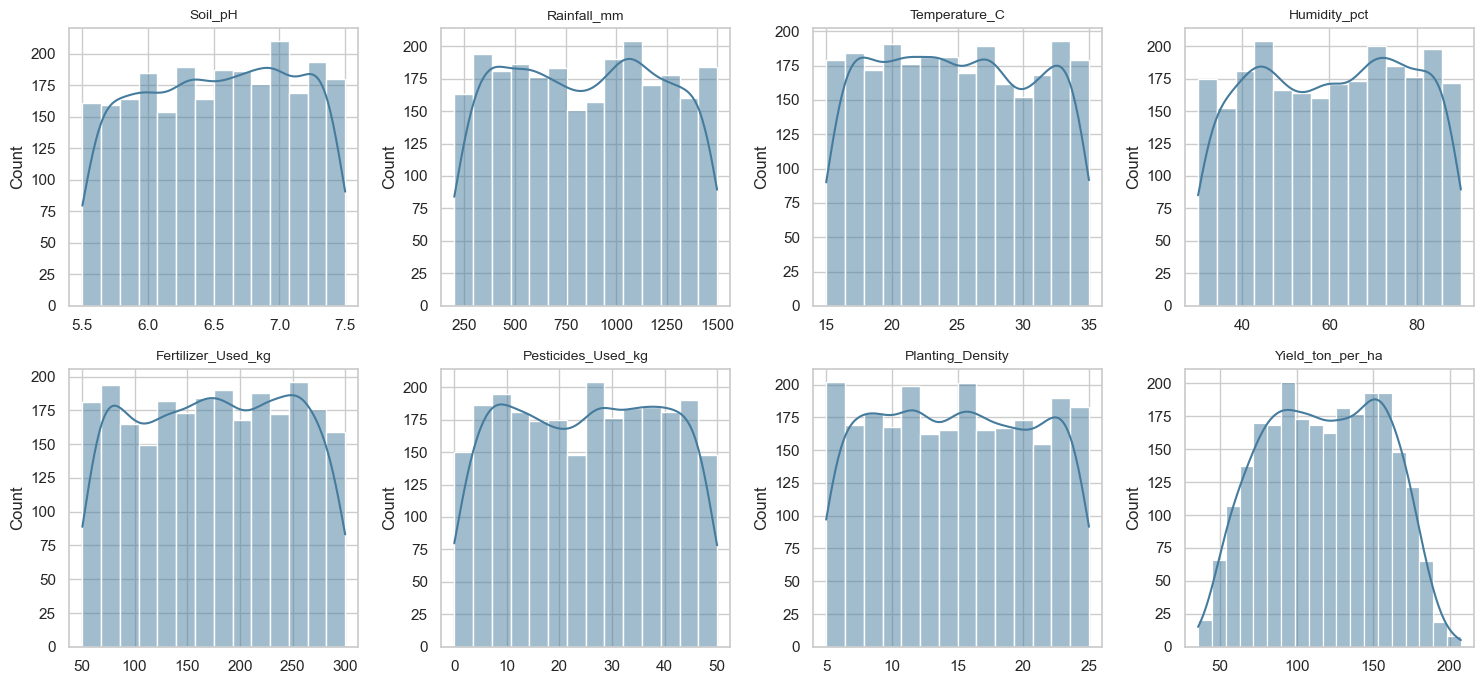

In [6]:
# Feature distributions
fig, axes = plt.subplots(2, 4, figsize=(15,7))
for ax, c in zip(axes.ravel(), NUMERIC + [TARGET]):
    sns.histplot(maize[c], kde=True, ax=ax, color="#457b9d"); ax.set_title(c, fontsize=10); ax.set_xlabel("")
plt.tight_layout(); plt.show()

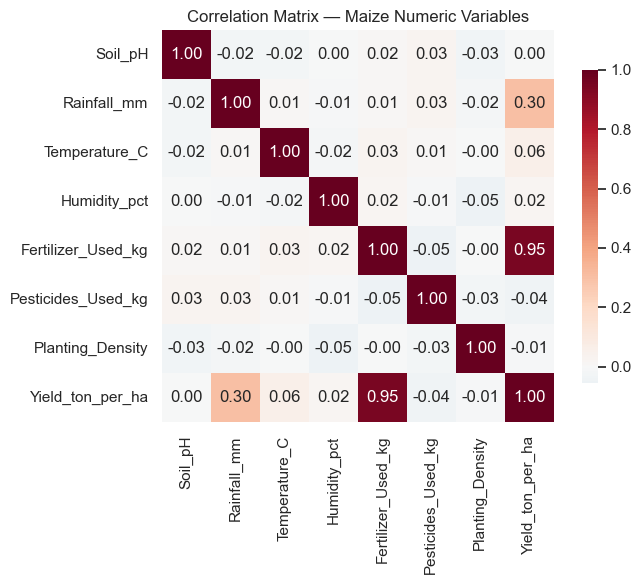

In [7]:
# Correlation matrix
plt.figure(figsize=(7.5,6))
sns.heatmap(maize[NUMERIC+[TARGET]].corr(), annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, square=True, cbar_kws={"shrink":.8})
plt.title("Correlation Matrix — Maize Numeric Variables"); plt.tight_layout(); plt.show()

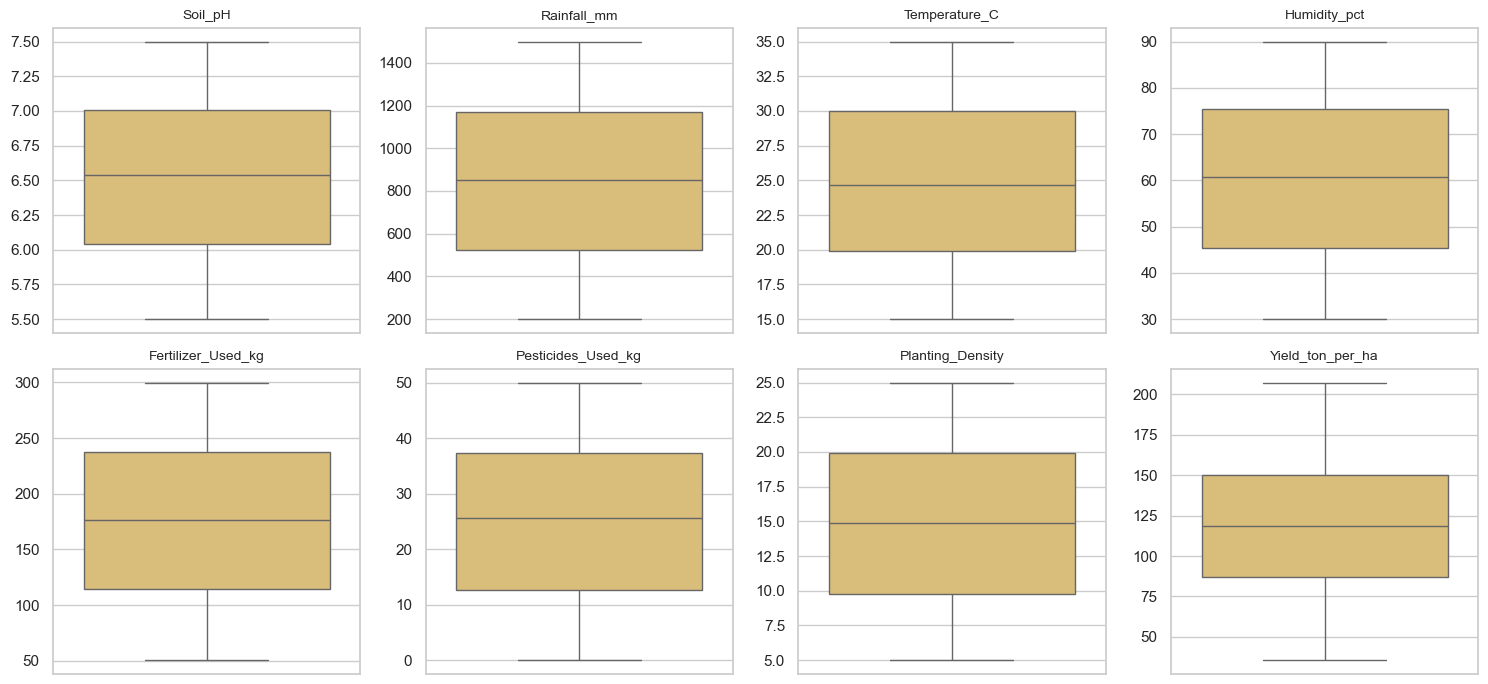

In [8]:
# Outlier inspection via boxplots
fig, axes = plt.subplots(2, 4, figsize=(15,7))
for ax, c in zip(axes.ravel(), NUMERIC + [TARGET]):
    sns.boxplot(y=maize[c], ax=ax, color="#e9c46a"); ax.set_title(c, fontsize=10); ax.set_ylabel("")
plt.tight_layout(); plt.show()

**What EDA shows:** `Fertilizer_Used_kg` is by far the strongest correlate of yield
(≈0.95), followed by `Rainfall_mm` (≈0.30); the remaining variables are weakly related on
their own. Distributions are well-behaved and the box plots reveal no extreme values — an
early sign this dataset is internally consistent.

## 4. Data Cleaning (3.3)

Remove duplicate records, validate every value against a physically/agronomically possible
range, and standardise categorical text. Out-of-range numbers are set to `NaN` so the
missing-data stage handles them uniformly.

In [9]:
before = len(maize)
maize = maize.drop_duplicates().reset_index(drop=True)
print("Duplicate rows removed:", before - len(maize))

# standardise categorical text (defensive)
for c in CATEG:
    maize[c] = maize[c].astype(str).str.strip()

# validity rules: (min, max);  None = unbounded on that side
rules = {"Soil_pH":(0,14), "Rainfall_mm":(0,None), "Temperature_C":(-10,60),
         "Humidity_pct":(0,100), "Fertilizer_Used_kg":(0,None),
         "Pesticides_Used_kg":(0,None), "Planting_Density":(0,None),
         "Yield_ton_per_ha":(0,None)}
for col,(lo,hi) in rules.items():
    m = pd.Series(False, index=maize.index)
    if lo is not None: m |= maize[col] < lo
    if hi is not None: m |= maize[col] > hi
    if m.any():
        print(f"  {col}: {int(m.sum())} out-of-range value(s) -> set to NaN")
        maize.loc[m, col] = np.nan
print("Range validation complete.")

Duplicate rows removed: 0
Range validation complete.


## 5. Missing Data Handling (3.4)

Policy, applied in order:
1. **Summarise** the proportion missing per column.
2. **Drop** any record missing more than 50% of its fields (too little signal to trust).
3. **Numeric** gaps → filled with the column **median** (robust to outliers).
4. **Categorical** gaps → filled with the column **mode**.

After the correct `None` handling in Step 1, this dataset has **no genuine gaps**, so nothing
is imputed here — but the routine is in place so the pipeline stays robust to future data.

In [10]:
missing_pct = (maize.isna().mean()*100).round(2)
print("Missing % per column:\n", missing_pct[missing_pct > 0] if (missing_pct>0).any() else "  (none)")

# 2) drop rows >50% missing
row_frac = maize.isna().mean(axis=1)
maize = maize[row_frac <= 0.50].reset_index(drop=True)

# 3) numeric -> median, 4) categorical -> mode
for c in NUMERIC:
    if maize[c].isna().any(): maize[c] = maize[c].fillna(maize[c].median())
for c in CATEG:
    if maize[c].isna().any(): maize[c] = maize[c].fillna(maize[c].mode().iloc[0])

print("Remaining missing cells after handling:", int(maize.isna().sum().sum()))

Missing % per column:
   (none)
Remaining missing cells after handling: 0


In [11]:
# Save the cleaned, human-readable maize dataset
maize.drop(columns=["Crop"]).to_csv("maize_clean.csv", index=False)
print("Saved -> maize_clean.csv", maize.shape)

Saved -> maize_clean.csv (2477, 13)


## 6. Data Preprocessing — Encoding (3.6)

Machine-learning models need numeric input. The four categorical columns
(`Region`, `Soil_Type`, `Irrigation`, `Previous_Crop`) are converted with **one-hot
encoding** (`drop_first=True` avoids the dummy-variable trap). The constant `Crop` column is
dropped since every row is maize.

> *Note on feature engineering:* Chapter 3.6 also describes Growing Degree Days and a
> moisture-availability index. Those require variables not present in this dataset (e.g.
> daily min/max temperature, soil-moisture content), so they are noted as a limitation rather
> than fabricated. The engineered features can be added if a richer weather feed is integrated later.

In [12]:
model_df = maize.drop(columns=["Crop"]).copy()
model_df = pd.get_dummies(model_df, columns=CATEG, drop_first=True)
X = model_df.drop(columns=[TARGET])
y = model_df[TARGET]
print("Feature matrix shape:", X.shape)
X.head()

Feature matrix shape: (2477, 19)


,Soil_pH,Rainfall_mm,Temperature_C,Humidity_pct,Fertilizer_Used_kg,Pesticides_Used_kg,Planting_Density,Region_Region_B,Region_Region_C,Region_Region_D,Soil_Type_Loam,Soil_Type_Sandy,Irrigation_Flood,Irrigation_Rainfed,Irrigation_Sprinkler,Previous_Crop_Maize,Previous_Crop_No_Previous_Crop,Previous_Crop_Rice,Previous_Crop_Wheat
0,7.01,1485.4,19.7,40.3,105.1,10.2,23.2,False,True,False,False,True,False,False,False,False,False,True,False
1,6.79,1054.3,26.4,62.0,257.8,42.7,23.7,False,False,True,True,False,False,False,False,False,True,False,False
2,5.96,744.6,20.4,70.9,195.8,25.5,15.6,False,False,True,False,True,False,False,False,True,False,False,False
3,6.94,846.1,32.4,86.6,263.2,7.4,21.5,False,True,False,True,False,False,True,False,False,False,False,True
4,6.67,209.5,18.3,42.7,219.5,20.6,17.2,False,True,False,True,False,True,False,False,False,True,False,False


## 7. Train/Test Split (3.8)

An **80/20** split, **stratified by Region** so every maize-growing region is proportionally
represented in both sets. The split is done *before* scaling so the scaler never sees test data.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RNG, stratify=maize["Region"])
print("Train:", X_train.shape[0], "| Test:", X_test.shape[0])

Train: 1981 | Test: 496


## 8. Normalisation — Standardisation (3.7)

Each numeric feature is rescaled to mean 0, standard deviation 1 using the formula
$z = (x-\mu)/\sigma$. Critically, $\mu$ and $\sigma$ are learned from the **training set
only** and then applied to the test set, so no information leaks from test into training.
(Tree models like XGBoost are scale-invariant, but standardisation is applied for a fair,
consistent comparison with the Linear Regression baseline.)

In [14]:
scaler = StandardScaler()
X_train_s, X_test_s = X_train.copy(), X_test.copy()
X_train_s[NUMERIC] = scaler.fit_transform(X_train[NUMERIC])   # fit on TRAIN only
X_test_s[NUMERIC]  = scaler.transform(X_test[NUMERIC])        # apply to TEST
X_train_s[NUMERIC].describe().loc[["mean","std"]].round(3)

,Soil_pH,Rainfall_mm,Temperature_C,Humidity_pct,Fertilizer_Used_kg,Pesticides_Used_kg,Planting_Density
mean,-0.0,-0.0,-0.0,0.0,-0.0,0.0,0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0


## 9. Preliminary XGBoost Model (3.9.3)

A first XGBoost regressor to confirm the prepared data trains successfully and to give a
baseline reading. **Final tuning and the full Linear Regression / Random Forest / XGBoost
comparison belong to the next project stage** — this is only a proof that the data pipeline works.

**Why XGBoost:** it builds decision trees *sequentially*, each new tree correcting the errors
of the ones before it, and adds a regularisation term that penalises overly complex trees —
giving high accuracy with strong resistance to overfitting on tabular farm data.

In [15]:
xgb = XGBRegressor(n_estimators=400, learning_rate=0.05, max_depth=5,
                   subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
                   random_state=RNG, n_jobs=-1, objective="reg:squarederror")
xgb.fit(X_train, y_train)          # trees are scale-invariant -> unscaled X keeps importances readable
pred = xgb.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, pred))
mae  = mean_absolute_error(y_test, pred)
r2   = r2_score(y_test, pred)
tol  = 0.10 * y_test.mean()
acc  = (np.abs(y_test.values - pred) <= tol).mean() * 100
print(f"RMSE : {rmse:.2f} ton/ha")
print(f"MAE  : {mae:.2f} ton/ha")
print(f"R^2  : {r2:.3f}")
print(f"Accuracy within +/-10% ({tol:.1f} ton/ha): {acc:.1f}%")

RMSE : 5.84 ton/ha
MAE  : 4.64 ton/ha
R^2  : 0.977
Accuracy within +/-10% (11.6 ton/ha): 94.6%


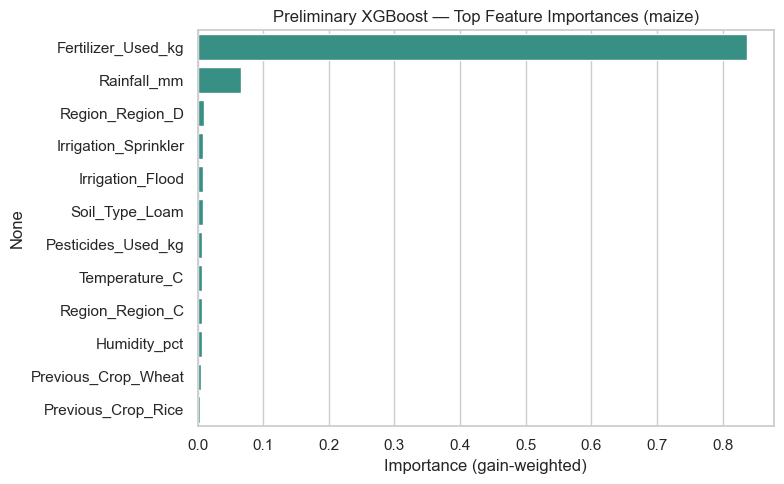

In [16]:
# Which variables drive the prediction?
imp = pd.Series(xgb.feature_importances_, index=X.columns).sort_values(ascending=False).head(12)
plt.figure(figsize=(8,5))
sns.barplot(x=imp.values, y=imp.index, color="#2a9d8f")
plt.title("Preliminary XGBoost — Top Feature Importances (maize)")
plt.xlabel("Importance (gain-weighted)"); plt.tight_layout(); plt.show()

## 10. Summary

* **Genuine missing data:** 0 — after correcting the `"None"` sentinel that a naive read would
  have mistaken for ~1,100 missing maize cells.
* **Duplicates / out-of-range values:** none found; validation routine retained for robustness.
* **Cleaned dataset:** `maize_clean.csv` (2,477 maize records, 12 columns).
* **Model-ready features:** 19 after one-hot encoding; standardised; 80/20 region-stratified split.
* **Preliminary XGBoost:** strong fit (R² ≈ 0.98), driven mainly by **fertiliser** then
  **rainfall** — agronomically sensible.

**Next stage:** build the Linear Regression baseline and Random Forest, tune XGBoost
hyper-parameters, and compare all three on RMSE / MAE / R² / accuracy (Chapter 3.9–3.11).